In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

In [6]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [7]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [8]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

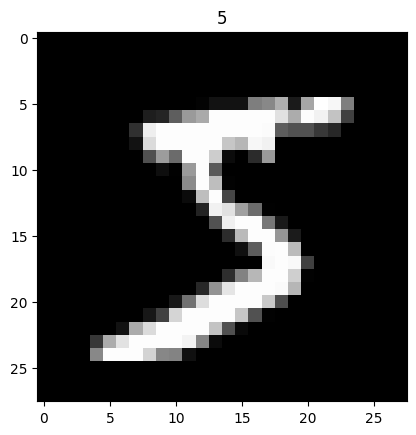

In [9]:
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

# preprocessing

In [10]:
#normalizing 
x_train_normalized = x_train / 255.0
x_test_normalized = x_test / 255.0

In [11]:
#resizing the data
x_trainr = x_train_normalized.reshape(60000, 28, 28, 1)#adding 1 dimension for color channel
x_testr = x_test_normalized.reshape(10000, 28, 28, 1)#1=grayscale ,3=RGB

In [12]:
x_trainr.shape

(60000, 28, 28, 1)

# cnn model
convulutions scans the image and finds features or patterns or filters, in our case 3x3 matrix, output size=(N-F+1)

In [13]:
model=keras.Sequential()

#1st convlutional layer
model.add(Conv2D(32,(3,3),input_shape=(28,28,1),activation='relu'))#32 feature detectors of 3x3 size (filters or kernels) output size = 26x26x32
model.add(MaxPooling2D(pool_size=(2,2)))

#2nd convulational layer
model.add(Conv2D(64,(3,3),activation='relu'))#output size = 11x11x64 ;that is 64 filters and 64 feature maps
model.add(MaxPooling2D(pool_size=(2,2)))

#3rd convulational layer
model.add(Conv2D(128,(3,3),activation='relu'))#output size = 3x3x128 ;that is 128 filters and 128 feature maps



#flatten
model.add(Flatten())

#fully connected layer
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax')) # 10 classes/neurons for digits 0-9

c:\Users\SIDDHARTHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
model.fit(x_trainr,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9599 - loss: 0.1318
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9867 - loss: 0.0433
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9903 - loss: 0.0315
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9922 - loss: 0.0247
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9940 - loss: 0.0194


In [16]:
model.evaluate(x_testr,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9910 - loss: 0.0287


[0.02874622493982315, 0.9909999966621399]

In [17]:
y_pred=model.predict(x_testr)
y_pred_labels=np.argmax(y_pred,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [19]:
import pickle
with open ('model.pkl','wb') as f:
    pickle.dump(model,f)